   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
Confusion Matrix:
[[13  0  0]
 [ 0 11  2]
 [ 0  0 12]]

Accuracy: 94.74 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.85      0.92        13
   virginica       0.86      1.00      0.92        12

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95

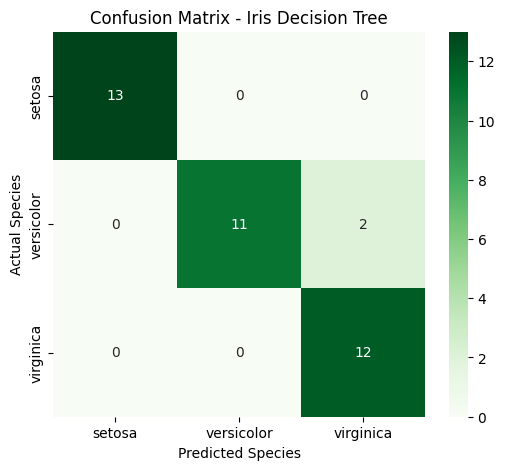

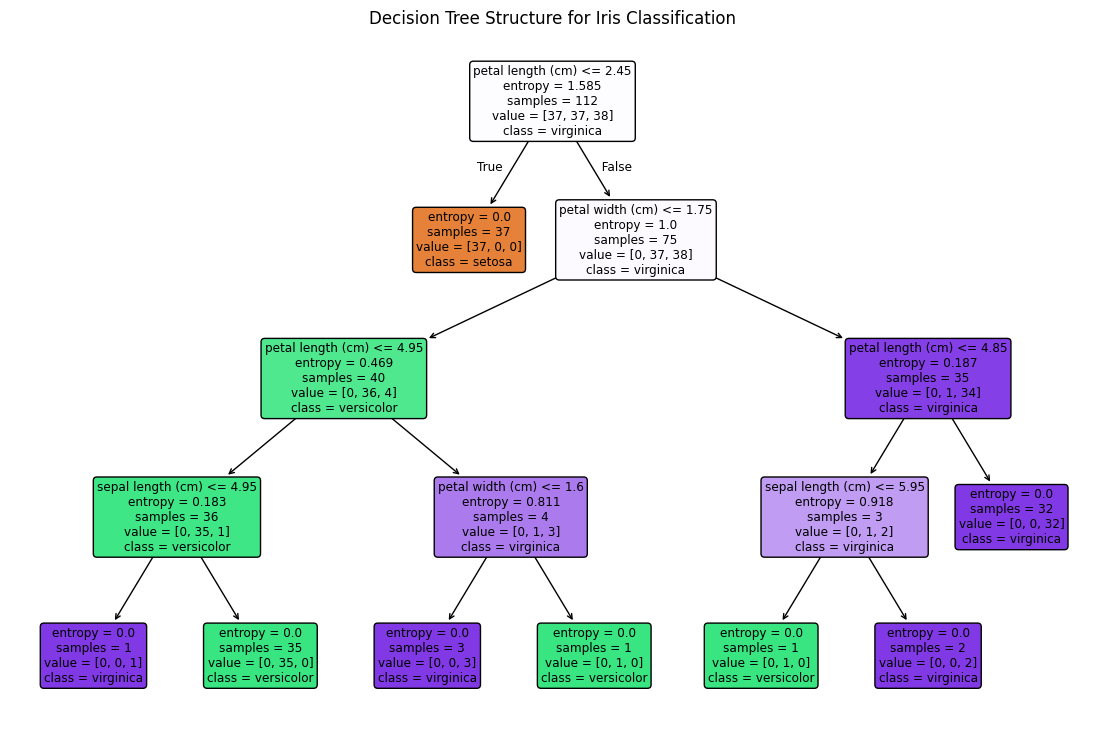

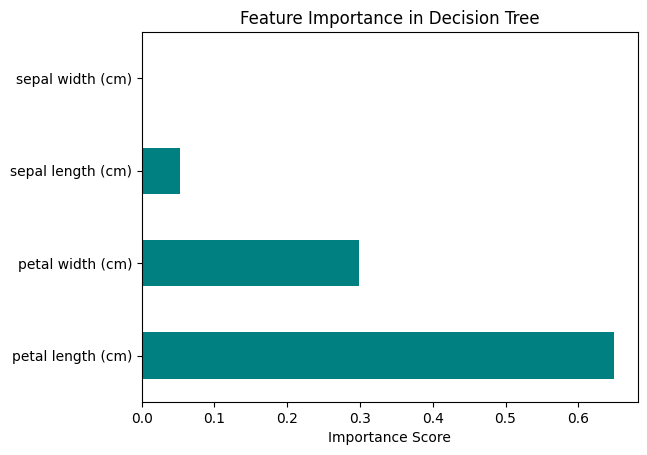

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

data = load_iris()
features = data.data
labels = data.target
class_labels = data.target_names
feature_labels = data.feature_names

df = pd.DataFrame(features, columns=feature_labels)
df['species'] = labels
print(df.head())

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.25, random_state=7, stratify=labels
)

clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=7)
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

conf_matrix = confusion_matrix(y_test, predictions)
model_accuracy = accuracy_score(y_test, predictions)

print("Confusion Matrix:")
print(conf_matrix)
print("\nAccuracy:", round(model_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=class_labels))

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Greens",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix - Iris Decision Tree")
plt.show()

plt.figure(figsize=(14, 9))
plot_tree(clf, filled=True, rounded=True,
          feature_names=feature_labels, class_names=class_labels)
plt.title("Decision Tree Structure for Iris Classification")
plt.show()

importances = pd.Series(clf.feature_importances_, index=feature_labels)
importances.sort_values(ascending=False).plot(kind='barh', color='teal')
plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance Score")
plt.show()